# **CAPM Notebook**

## We will:
- Understand the CAPM formula.
- Use log returns for both the Apple stock (risky) and the S&P500 (market proxy).
- Calculate and plot the Security Market Line.
- Run a linear regression based on the CAPM equation.
- Make some simple predictions using our fitted model.


## 1. Introduction to CAPM <a name="introduction"></a>
The Capital Asset Pricing Model (CAPM) is a fundamental concept in finance used to describe the relationship between *systematic risk* and *expected returns* of assets, typically stocks. In its basic form, the model is:
\begin{align}
R_i - R_f = \alpha + \beta (R_m - R_f) + \epsilon
\end{align}
where:
- $R_i$ is the return of the individual stock (e.g., Apple).
- $R_f$ is the risk-free rate (often short-term Treasury bill rate). 
  - *In our case, we might not have actual T-bill data, so we could assume $R_f \approx 0$ or use a small constant, but we’ll demonstrate the general idea. If you want to treat S&P500 as the 'market', that's typical, but be aware that strictly speaking we need $R_f$ data for a pure CAPM. For demonstration, we’ll keep it simple.*
- $R_m$ is the return of the market portfolio (here, we use the S&P500 as a proxy).
- $\alpha$ (alpha) is the stock’s constant component of return not explained by market movements (often assumed to be 0 in theory, but can be tested).
- $\beta$ (beta) measures how much the stock moves relative to the market.
- $\epsilon$ (epsilon) is the error term.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import datetime

## 2. Import and Explore the Data <a name="data"></a>
- Apple (AAPL) (risky asset)
- S&P500 index (market proxy)

In [6]:
# 1. Read the CSV data
df = pd.read_csv('stock.csv', parse_dates=['Date'])

# 2. Sort by date if not already
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

# Quick look at the data
df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


## 3. Calculate Returns <a name="returns"></a>
We’ll calculate the *log returns* for Apple and the S&P500. Log returns are computed as:
$$ R_{t} = \ln\left(\frac{P_{t}}{P_{t-1}}\right) $$
This helps with some statistical properties and is commonly used.

### Risk-Free Rate
In a true CAPM setting, we would also incorporate $R_f$, the risk-free rate. If you don't have that, we can approximate zero or a small constant. (Alternatively, if your dataset has a column for T-bills, use that. For now, let's assume $R_f = 0$ just to demonstrate the mechanics of the CAPM regression.)

In [7]:
# Calculate log returns for Apple and for the SP500
df['AAPL_Return'] = np.log(df['AAPL'] / df['AAPL'].shift(1))
df['SPX_Return'] = np.log(df['sp500'] / df['sp500'].shift(1))

# Approximate risk-free rate as zero for daily (purely for demonstration)
risk_free_rate = 0.0

# Select time frame
start_date = '2012-01-01'
end_date = '2013-01-01'

df = df[start_date:end_date]

# Drop any rows with NaNs introduced by shift
df.dropna(inplace=True)
df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500,AAPL_Return,SPX_Return
Date,,,,,,,,,,,
2012-01-13,59.972858,74.599998,30.07,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966,-0.003757,-0.004960
2012-01-17,60.671429,75.239998,30.25,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044,0.011581,0.003547
2012-01-18,61.301430,75.059998,30.33,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039,0.010330,0.011047
2012-01-19,61.107143,75.559998,30.42,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000,-0.003174,0.004927
2012-01-20,60.042858,75.519997,30.51,12.64,190.929993,188.520004,26.600000,291.900879,1315.380005,-0.017570,0.000669


## 4. Visualize the Market vs. Asset <a name="visualize"></a>
A quick plot of the log returns can be useful to see how Apple moves compared to the S&P500.

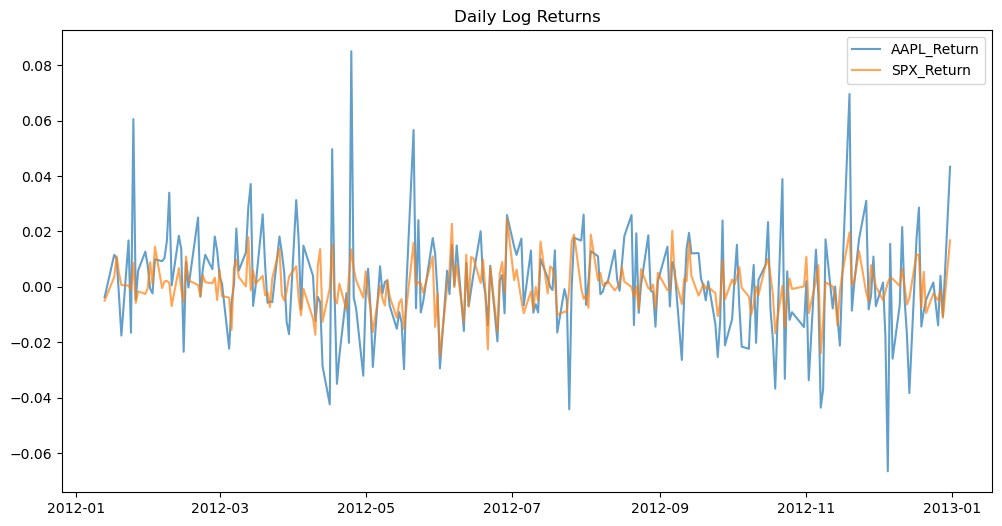

In [8]:
# Plot daily log returns
plt.figure(figsize=(12,6))
plt.plot(df.index, df['AAPL_Return'], label='AAPL_Return', alpha=0.7)
plt.plot(df.index, df['SPX_Return'], label='SPX_Return', alpha=0.7)
plt.title('Daily Log Returns')
plt.legend()
plt.show()

## 5. Security Market Line (SML) <a name="sml"></a>
In theory, for any stock $i$:
\begin{align}
E[R_i] = R_f + \beta_i \bigl(E[R_m] - R_f\bigr)
\end{align}
where $\beta_i$ is the sensitivity of stock $i$ to the market portfolio. Plotting $E[R_i]$ vs. $\beta_i$ across many stocks forms the *Security Market Line (SML)*.

For this small demo, we only have **one** stock (Apple) and the market (S&P500). We’ll still illustrate how to compute an estimate of $\beta$ and see how the expected returns line up.


In [ ]:
# Step 1: Estimate the average returns for Apple and the market
mean_AAPL = df['AAPL_Return'].mean() # average daily log return
mean_SPX = df['SPX_Return'].mean()

print(f"Mean daily log return for AAPL: {mean_AAPL:.5f}")
print(f"Mean daily log return for SP500: {mean_SPX:.5f}")

# Step 2: Estimate the Beta
# Beta is Cov(R_i, R_m) / Var(R_m)
cov_matrix = np.cov(df['AAPL_Return'], df['SPX_Return'])
cov_AAPL_SPX = cov_matrix[0,1]
var_SPX = cov_matrix[1,1]

beta = cov_AAPL_SPX / var_SPX
print(f"Estimated Beta for AAPL: {beta:.2f}")

# In CAPM, E[R_i] = R_f + beta_i * (E[R_m] - R_f)
# We'll treat daily R_f = 0 for demonstration
capm_return_aapl = beta * mean_SPX
print(f"CAPM Implied Mean Return for AAPL (daily, ignoring alpha): {capm_return_aapl:.5f}")

Mean daily log return for AAPL: 0.00096
Mean daily log return for SP500: 0.00040
Estimated Beta for AAPL: 1.28
CAPM Implied Mean Return for AAPL (daily, ignoring alpha): 0.00051


### Plot a Mini SML
With only one stock, we can’t truly draw a full SML. But let’s illustrate the line that the CAPM suggests: if we had a range of betas, how would their expected returns line up? We’ll plot a line from $\beta = 0$ to $\beta = 2$, for example, using the formula:

\begin{align}
E[R] = R_f + \beta (E[R_m] - R_f)
\end{align}


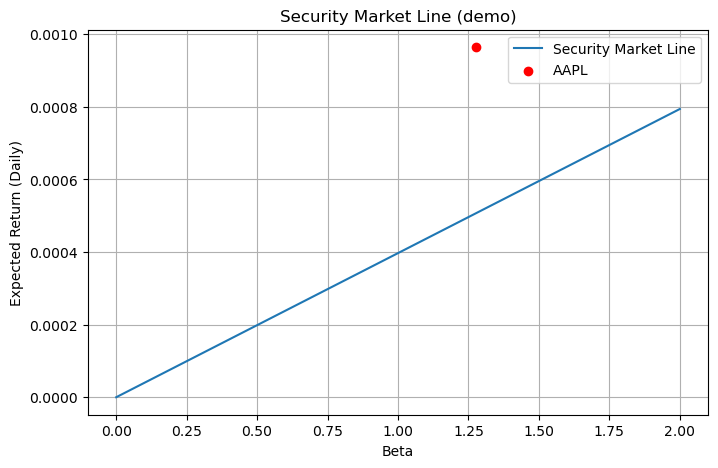

In [12]:
# Create an array of hypothetical betas
betas = np.linspace(0, 2, 50)

# Compute expected return for each beta
# E[R] = R_f + beta * (mean_SPX - R_f); again R_f = 0 for demonstration
sml_returns = betas * mean_SPX

plt.figure(figsize=(8,5))
plt.plot(betas, sml_returns, label='Security Market Line')

# Plot the actual point for Apple
plt.scatter(beta, mean_AAPL, color='red', label='AAPL')
plt.title('Security Market Line (demo)')
plt.xlabel('Beta')
plt.ylabel('Expected Return (Daily)')
plt.legend()
plt.grid(True)
plt.show()

## 6. CAPM Regression <a name="capm-regression"></a>
One standard approach to *test* the CAPM is to run a linear regression on:
\begin{align}
R_i - R_f = \alpha + \beta (R_m - R_f) + \epsilon
\end{align}
Given we’re approximating $R_f = 0$, this simplifies to:
\begin{align}
R_i = \alpha + \beta R_m + \epsilon
\end{align}
We want to see if $\alpha$ is significantly different from zero, and get an estimate for $\beta$.


In [14]:
# Prepare the regression variables
# Dependent variable: R_i (AAPL)
# Independent variable: R_m (SPX)
# Here we can just do a simple linear regression: R_i = alpha + beta * R_m

X = df['SPX_Return']
y = df['AAPL_Return']

# statsmodels requires us to add a constant term for alpha
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            AAPL_Return   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     104.5
Date:                Sat, 01 Mar 2025   Prob (F-statistic):           1.34e-20
Time:                        10:10:39   Log-Likelihood:                 663.11
No. Observations:                 242   AIC:                            -1322.
Df Residuals:                     240   BIC:                            -1315.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.453      0.6

### Interpretation of the Regression Results
1. **const** is our estimate for $\alpha$. If it’s close to zero (and not statistically significant), that’s consistent with the CAPM theory (though real data often deviates).  
2. **SPX_Return** coefficient is our estimated $\beta$.
3. **R-squared** and other statistical measures tell us how well the model fits.
